# AIRPATH-AI P0-3 — downstream freeze and final robustness

Freezes `C_xgboost_current_pm` for downstream AIRPATH research, refreshes the
P0-2B scenario panel, and evaluates decision stability under global
multiplicative predicted-PM perturbations.

Load saved artifacts here. Regenerate with `python3 -m src.final_robustness`.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

OUTPUT = PROJECT_ROOT / "data/processed/final_robustness"

In [2]:
manifest = json.loads((OUTPUT / "freeze_manifest.json").read_text())
stability = pd.read_csv(OUTPUT / "stability_summary.csv")
oracle = pd.read_csv(OUTPUT / "baseline_oracle_quality.csv")
readiness = json.loads((OUTPUT / "readiness_decision.json").read_text())
manifest["frozen_forecaster"], readiness["classification"]

('C_xgboost_current_pm', 'A. READY TO FREEZE')

In [3]:
stability.loc[stability["summary_level"].eq("all")]

,summary_level,perturbation_scale,cases,top1_agreement_rate,mean_top3_overlap_fraction,mean_abs_travel_time_difference_minutes,mean_abs_predicted_exposure_difference,mean_decision_regret_difference,mode,delta_time_allowed_minutes
0,all,0.80,1800,1.0,1.0,0.0,123.056243,0.0,NaN,NaN
1,all,0.90,1800,1.0,1.0,0.0,61.528121,0.0,NaN,NaN
2,all,0.95,1800,1.0,1.0,0.0,30.764061,0.0,NaN,NaN
3,all,1.00,1800,1.0,1.0,0.0,0.000000,0.0,NaN,NaN
4,all,1.05,1800,1.0,1.0,0.0,30.764061,0.0,NaN,NaN
5,all,1.10,1800,1.0,1.0,0.0,61.528121,0.0,NaN,NaN
6,all,1.20,1800,1.0,1.0,0.0,123.056243,0.0,NaN,NaN


In [4]:
oracle.loc[oracle["summary_level"].isin(["all", "mode", "tolerance"])]

,summary_level,cases,oracle_optimal_agreement_rate,mean_decision_regret,median_decision_regret,max_decision_regret,zero_regret_rate,mode,delta_time_allowed_minutes,departure_time
0,all,1800,0.981111,0.000132,0.0,0.018633,0.981111,NaN,NaN,NaN
1,mode,900,0.988889,0.000121,0.0,0.018633,0.988889,motorbike,NaN,NaN
2,mode,900,0.973333,0.000144,0.0,0.018633,0.973333,walking,NaN,NaN
3,tolerance,300,1.000000,0.000000,0.0,0.000000,1.000000,NaN,0.0,NaN
4,tolerance,300,0.980000,0.000109,0.0,0.018633,0.980000,NaN,1.0,NaN
5,tolerance,300,0.976667,0.000171,0.0,0.018633,0.976667,NaN,2.0,NaN
6,tolerance,300,0.976667,0.000171,0.0,0.018633,0.976667,NaN,3.0,NaN
7,tolerance,300,0.976667,0.000171,0.0,0.018633,0.976667,NaN,5.0,NaN
8,tolerance,300,0.976667,0.000171,0.0,0.018633,0.976667,NaN,10.0,NaN


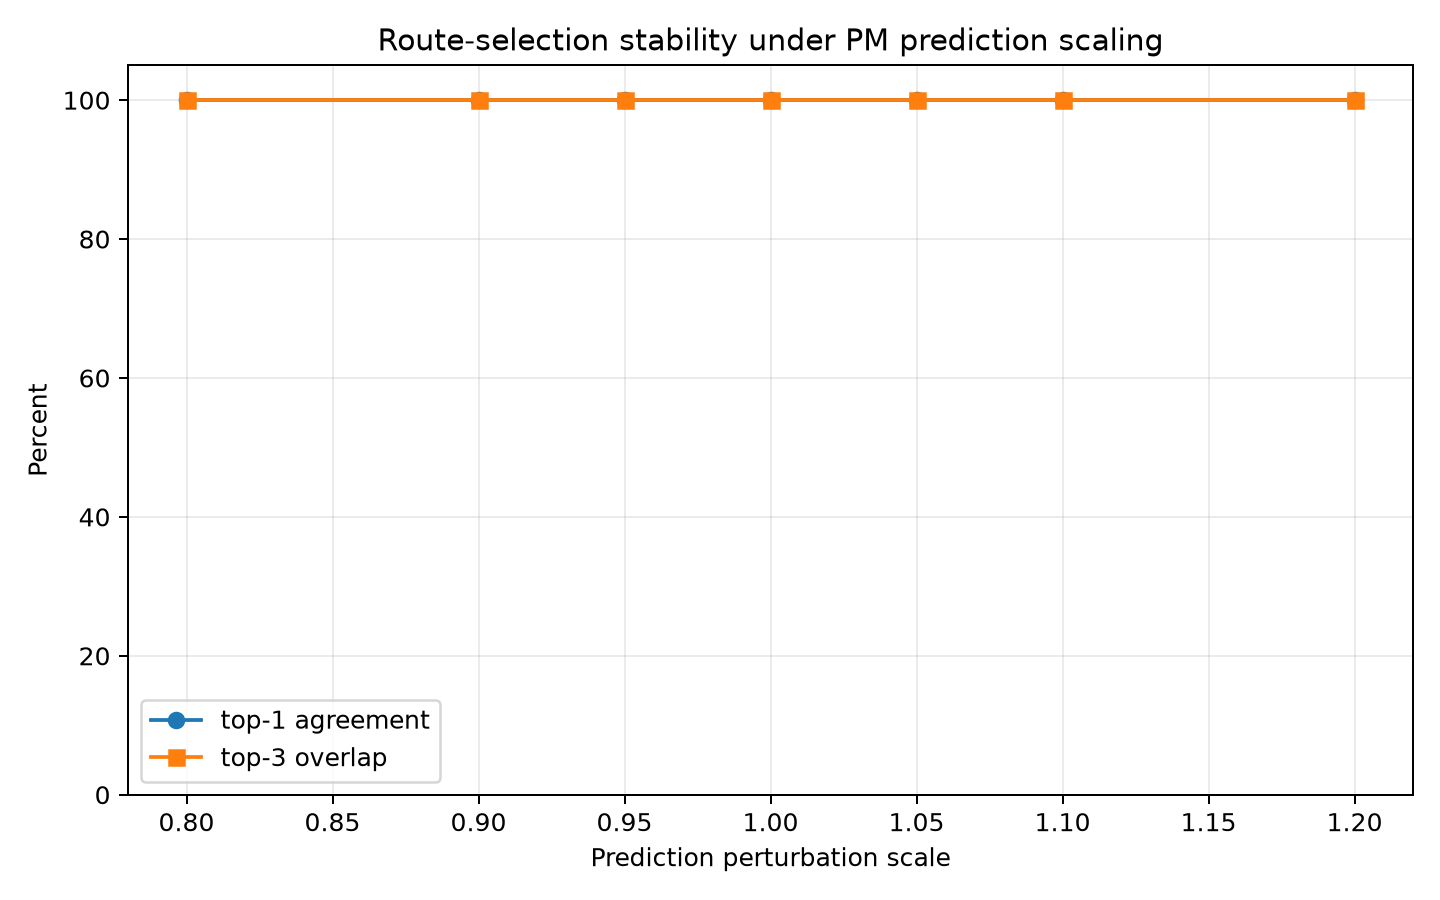

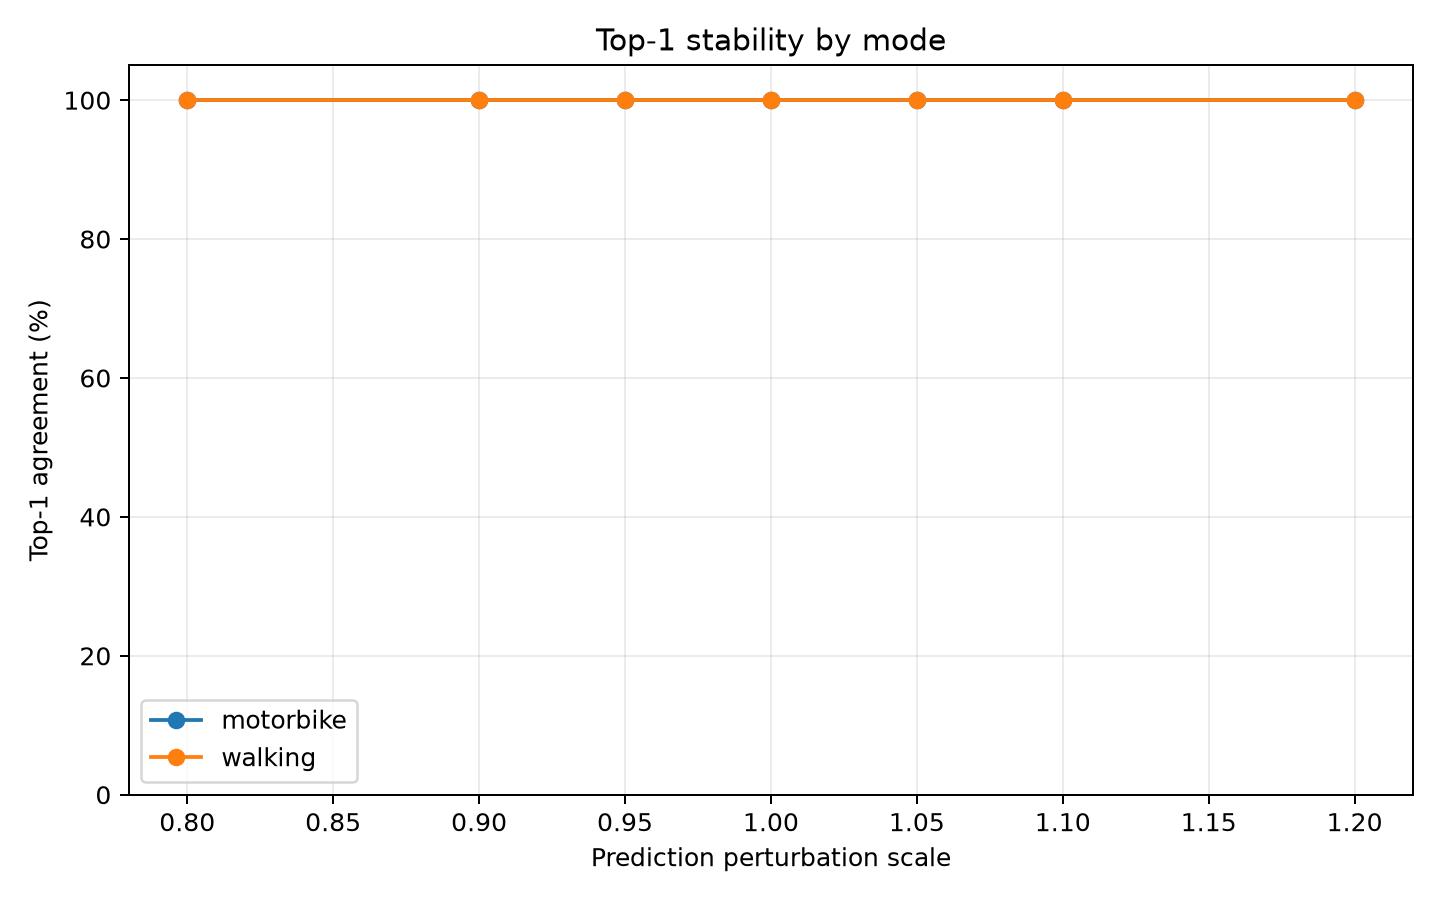

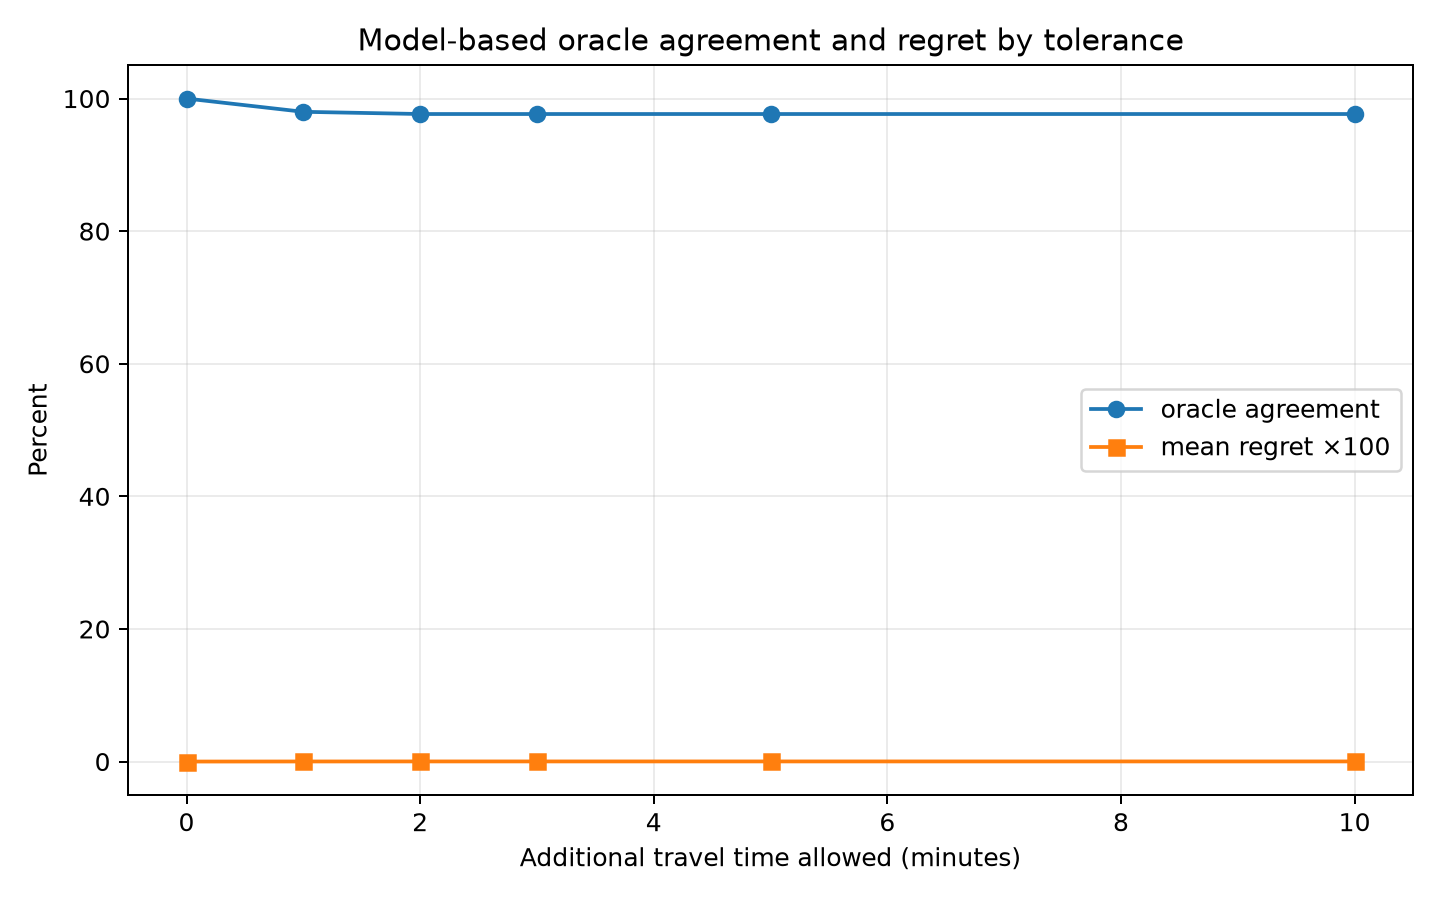

In [5]:
for name in (
    "perturbation_stability.png",
    "top1_stability_by_mode.png",
    "oracle_quality_by_tolerance.png",
):
    display(Image(filename=str(OUTPUT / name)))